In [1]:
import geopandas as gpd

# Load the GeoJSON
gdf = gpd.read_file("../../../../data/targeting/Zambia_roads.geojson")

# Check the first few rows
print(gdf.head())

# View CRS (Coordinate Reference System)
print(gdf.crs)

   name name:en       highway  surface smoothness width lanes oneway bridge  \
0  None    None   residential  unpaved       None  None  None   None   None   
1  None    None         track     None       None  None  None   None   None   
2  None    None  unclassified     None       None  None  None   None   None   
3  None    None         track   ground       None  None  None   None   None   
4  None    None         track   ground       None  None  None   None   None   

  layer source     osm_id   osm_type  \
0  None   None  395337762  ways_line   
1  None   None  685699903  ways_line   
2  None   None  487461377  ways_line   
3  None   None  598233655  ways_line   
4  None   None  598233656  ways_line   

                                            geometry  
0  LINESTRING (33.20075 -13.99153, 33.20079 -13.9...  
1  LINESTRING (29.69937 -11.53402, 29.69927 -11.5...  
2  LINESTRING (24.7487 -14.85586, 24.74862 -14.85...  
3  LINESTRING (29.45579 -11.54414, 29.45587 -11.5...  
4  LINEST

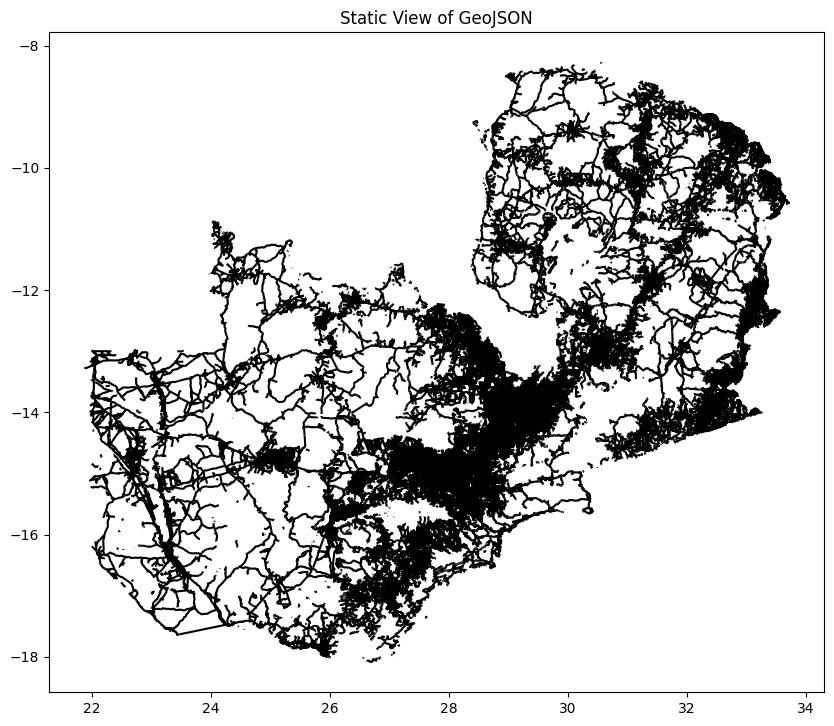

In [2]:
import matplotlib.pyplot as plt

gdf.plot(figsize=(10, 10), edgecolor='black')
plt.title("Static View of GeoJSON")
plt.show()

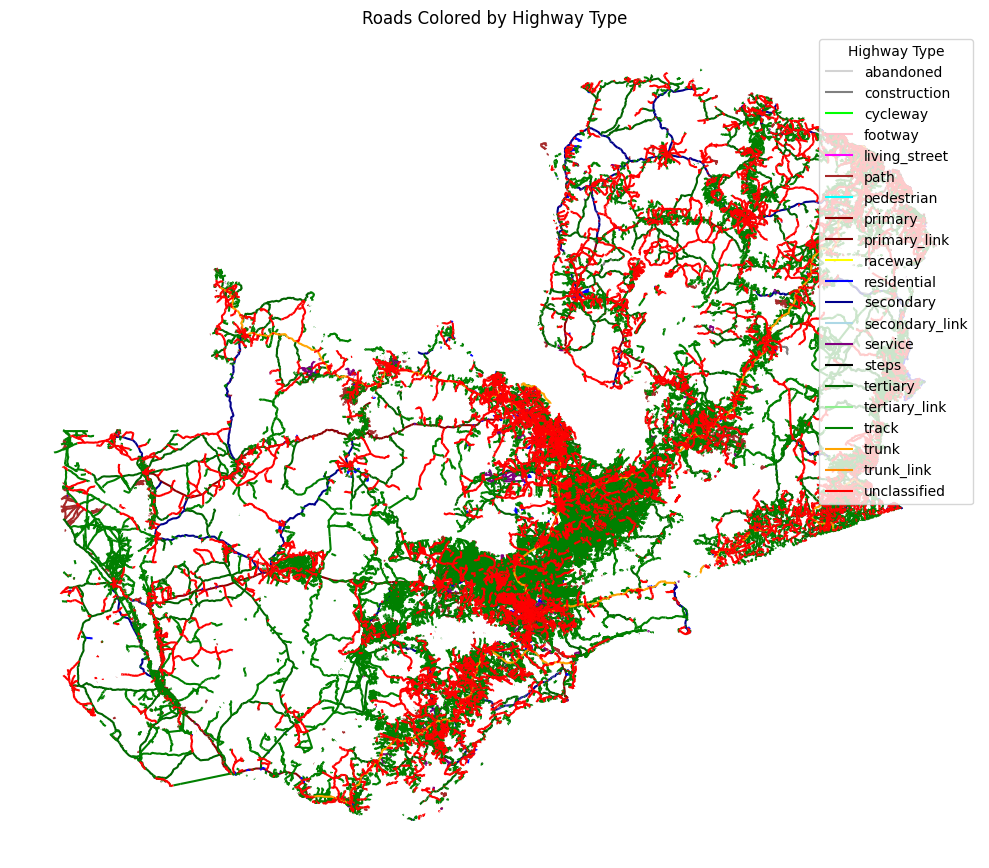

In [3]:
# Define color mapping for different 'highway' types
color_map = {
    "residential": "blue",
    "track": "green",
    "unclassified": "red",
    "trunk": "orange",
    "path": "brown",
    "service": "purple",
    "primary": "darkred",
    "tertiary": "darkgreen",
    "secondary": "darkblue",
    "construction": "gray",
    "footway": "pink",
    "secondary_link": "lightblue",
    "trunk_link": "darkorange",
    "tertiary_link": "lightgreen",
    "steps": "black",
    "primary_link": "maroon",
    "raceway": "yellow",
    "pedestrian": "cyan",
    "cycleway": "lime",
    "living_street": "magenta",
    "abandoned": "lightgray",
    None: "gray"  # default color for undefined types
}

# Apply color mapping
gdf['color'] = gdf['highway'].map(color_map).fillna("black")

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
for road_type, subset in gdf.groupby('highway'):
    subset.plot(ax=ax, color=subset['color'].iloc[0], label=road_type or 'unknown')

# Add legend and formatting
plt.legend(title="Highway Type")
plt.title("Roads Colored by Highway Type")
plt.axis('off')
plt.tight_layout()

# Save or show the figure
plt.savefig("roads_colored.png", dpi=300)
plt.show()


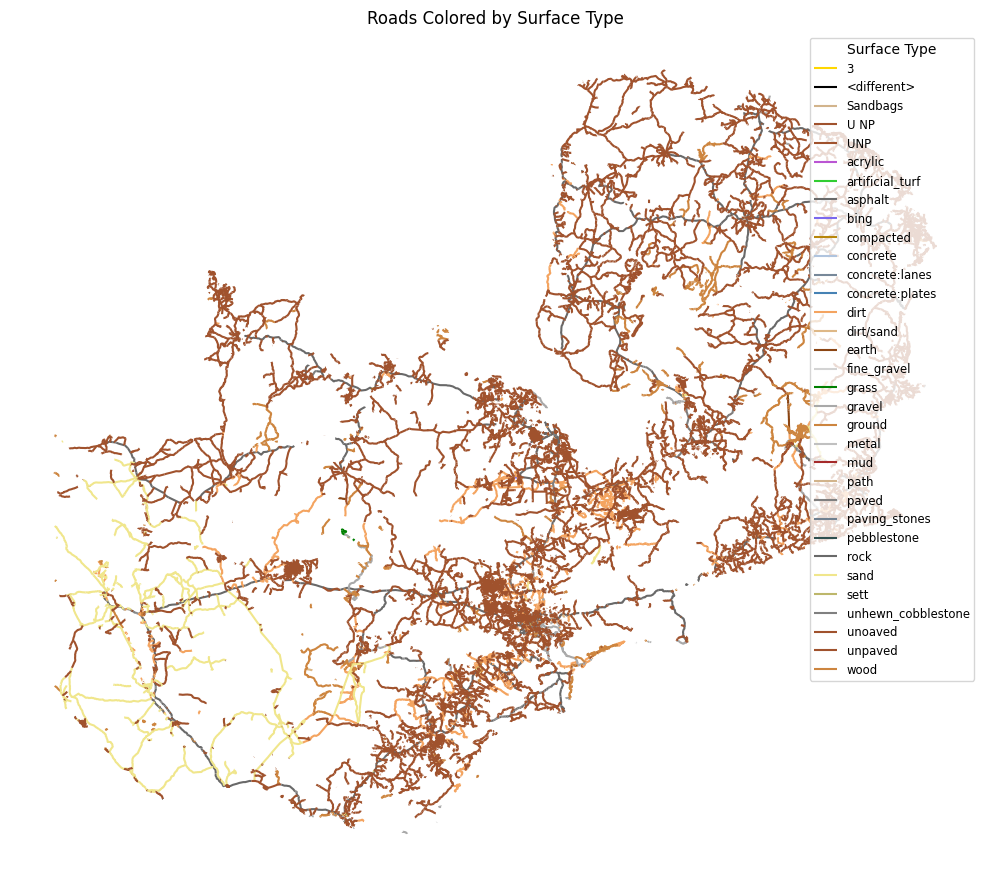

In [4]:
import matplotlib.pyplot as plt

# Define color mapping for different 'surface' types
surface_color_map = {
    'unpaved': 'sienna',
    None: 'gray',  # default color for undefined or None
    'ground': 'peru',
    'asphalt': 'dimgray',
    'dirt': 'sandybrown',
    'sand': 'khaki',
    'gravel': 'darkgray',
    'paved': 'gray',
    'grass': 'green',
    'fine_gravel': 'lightgray',
    'dirt/sand': 'burlywood',
    'compacted': 'darkgoldenrod',
    'concrete': 'lightsteelblue',
    'path': 'tan',
    'bing': 'mediumslateblue',
    'UNP': 'sienna',
    'earth': 'saddlebrown',
    'pebblestone': 'darkslategray',
    'concrete:plates': 'steelblue',
    'wood': 'peru',
    'paving_stones': 'slategray',
    'artificial_turf': 'limegreen',
    'sett': 'darkkhaki',
    'metal': 'silver',
    'unhewn_cobblestone': 'gray',
    'mud': 'brown',
    'Sandbags': 'tan',
    'rock': 'dimgray',
    'unoaved': 'sienna',
    'acrylic': 'mediumorchid',
    '<different>': 'black',
    'concrete:lanes': 'lightslategray',
    'U NP': 'sienna',
    '3': 'gold',
}

# Apply color mapping
gdf['color'] = gdf['surface'].map(surface_color_map).fillna('black')

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
for surface_type, subset in gdf.groupby('surface'):
    subset.plot(ax=ax, color=subset['color'].iloc[0], label=surface_type or 'unknown')

# Add legend and formatting
plt.legend(title="Surface Type", loc='best', fontsize='small')
plt.title("Roads Colored by Surface Type")
plt.axis('off')
plt.tight_layout()

# Save or show the figure
plt.savefig("roads_colored_by_surface.png", dpi=300)
plt.show()


In [6]:
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import nearest_points
from geopy.distance import geodesic

# Load irrigation data (sites)
sites_gdf = gpd.read_file("../../../../data/targeting/irrigation_data.geojson")

# Extract unique sites by site_id
sites_unique = sites_gdf.drop_duplicates(subset='site_id').copy()

# Create Point geometry from site center coordinates (x,y in properties)
sites_unique['geometry'] = sites_unique.apply(lambda row: Point(row['x'], row['y']), axis=1)
sites_unique = sites_unique.set_geometry('geometry')
sites_unique.crs = "EPSG:4326"  # Assuming lat/lon CRS

# Load roads data (assumed preloaded in variable `gdf`)
roads_gdf = gdf.copy()
roads_gdf = roads_gdf.to_crs("EPSG:4326")  # Match CRS if needed

# Create spatial index for roads
road_sindex = roads_gdf.sindex

# Function to find nearest road and geodesic distance
def nearest_geom_geodesic(point, roads_gdf, sindex, buffer_deg=0.01):
    # Get candidate roads using bounding box with small buffer
    bounds = point.buffer(buffer_deg).bounds
    candidates_idx = list(sindex.intersection(bounds))
    candidates = roads_gdf.iloc[candidates_idx]

    if candidates.empty:
        return None, None  # No nearby roads

    min_dist = float("inf")
    nearest_point = None

    for _, row in candidates.iterrows():
        candidate_geom = row.geometry
        np = nearest_points(point, candidate_geom)[1]
        dist = geodesic((point.y, point.x), (np.y, np.x)).meters
        if dist < min_dist:
            min_dist = dist
            nearest_point = np

    return nearest_point, min_dist

# Apply the nearest road function to each site
results = sites_unique['geometry'].apply(lambda pt: nearest_geom_geodesic(pt, roads_gdf, road_sindex))

# Extract nearest point and distance
sites_unique['nearest_road_point'] = results.apply(lambda x: x[0])
sites_unique['dist_to_road_meters'] = results.apply(lambda x: x[1] if x[1] is not None else None)

# Final result: sites with accurate distance to nearest road (in meters)
print(sites_unique[['site_id', 'x', 'y', 'dist_to_road_meters']])


         site_id          x          y  dist_to_road_meters
0     id_5092601  24.960879 -12.501002          1421.474238
1     id_3511469  33.243140 -12.309667           388.346237
11    id_5174895  28.092928 -15.191572             6.348381
14    id_5185003  23.668267 -15.449434          1948.562386
17    id_5204478  27.696359 -16.286994           844.821273
...          ...        ...        ...                  ...
1293  id_5159743  27.412643 -14.823165           143.255639
1294  id_5157121  28.443651 -14.746697           157.308615
1298  id_5189211  26.126557 -15.680689           253.547867
1300  id_5187039  28.076165 -15.553234           905.093536
1306  id_5230125  25.904471 -17.026457                  NaN

[438 rows x 4 columns]


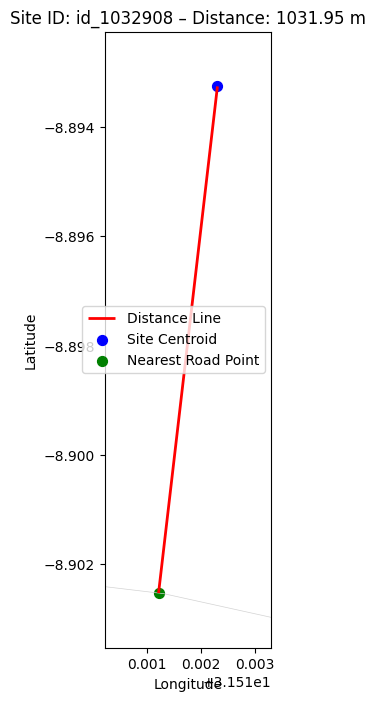

In [13]:
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import geopandas as gpd

# Choose one site to plot (first one with valid data)
example_row = sites_unique[sites_unique['site_id'] == "id_1032908"].dropna(subset=['nearest_road_point']).iloc[0]

site_point = example_row['geometry']
road_point = example_row['nearest_road_point']
connection_line = LineString([site_point, road_point])

# Create GeoDataFrames for plotting
site_gdf = gpd.GeoDataFrame(geometry=[site_point], crs="EPSG:4326")
road_point_gdf = gpd.GeoDataFrame(geometry=[road_point], crs="EPSG:4326")
line_gdf = gpd.GeoDataFrame(geometry=[connection_line], crs="EPSG:4326")

# Set zoom buffer (in degrees, since we're in EPSG:4326)
zoom_buffer = 0.001  # ~100 meters

# Compute bounds for zoom
minx = min(site_point.x, road_point.x) - zoom_buffer
maxx = max(site_point.x, road_point.x) + zoom_buffer
miny = min(site_point.y, road_point.y) - zoom_buffer
maxy = max(site_point.y, road_point.y) + zoom_buffer

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot roads (only those within zoom bounds)
roads_gdf.cx[minx:maxx, miny:maxy].plot(ax=ax, color='lightgray', linewidth=0.5)

# Plot connection line, site point, and road point
line_gdf.plot(ax=ax, color='red', linewidth=2, label="Distance Line")
site_gdf.plot(ax=ax, color='blue', markersize=50, label="Site Centroid")
road_point_gdf.plot(ax=ax, color='green', markersize=50, label="Nearest Road Point")

# Set zoom
ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])

# Add legend and title
plt.legend()
plt.title(f"Site ID: {example_row['site_id']} – Distance: {example_row['dist_to_road_meters']:.2f} m")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()
